# Customer Churn Prediction Project

- Whether customer will leave company

In [615]:
# importing libraries

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [616]:
# loading dataset

df = pd.read_csv("D:\\machine learning\\customer_churn_model\\telco_customer_churn_dataset.csv")
df

,Gender,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# EDA & Data Cleaning


In [617]:
df.shape

(7043, 18)

In [618]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   TenureMonths      7043 non-null   int64  
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   object 


In [619]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [620]:
df.describe()

,TenureMonths,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [621]:
df.isnull().sum()

Gender               0
Partner              0
Dependents           0
TenureMonths         0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [622]:
# filling null values

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)   

In [623]:
# dropping duplicates

print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

26


In [624]:
# Target Analsis

In [625]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1854
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

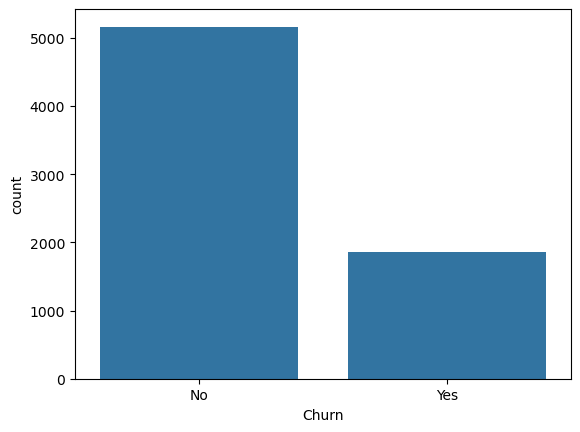

In [626]:
sns.countplot(x=df['Churn'])

In [627]:
# numerical features analysis

<Axes: xlabel='TenureMonths', ylabel='Count'>

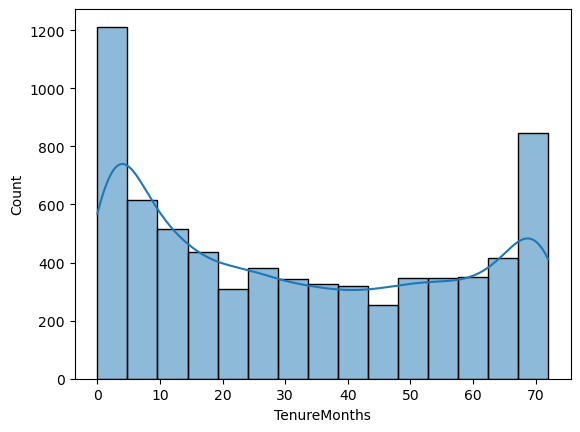

In [628]:
sns.histplot(df['TenureMonths'], kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

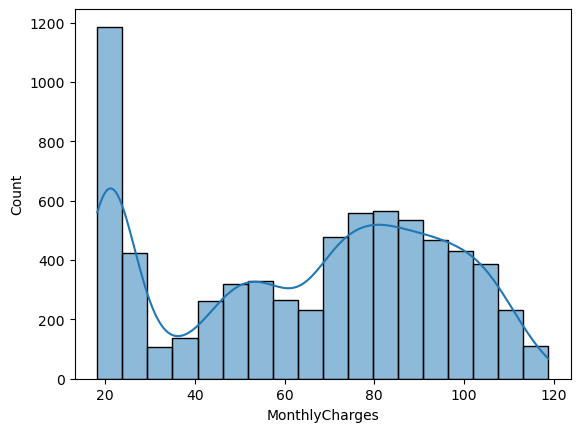

In [629]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: xlabel='TotalCharges', ylabel='Count'>

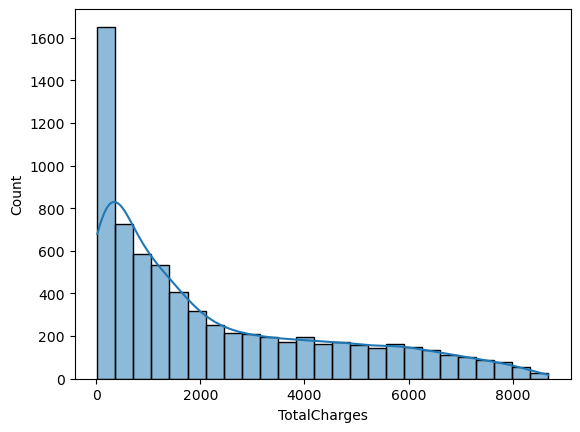

In [630]:
sns.histplot(df['TotalCharges'], kde=True)

In [631]:
# categorical features analysis

In [632]:
cat_col = ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod']

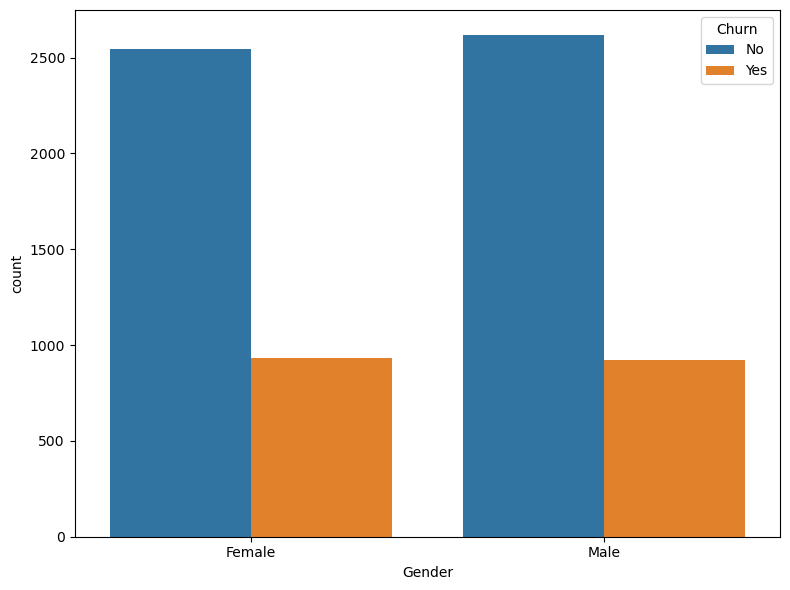

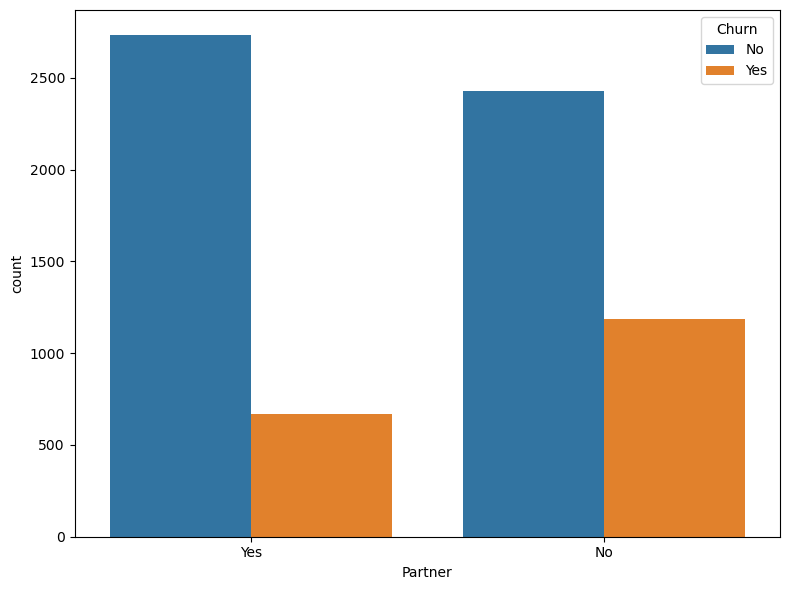

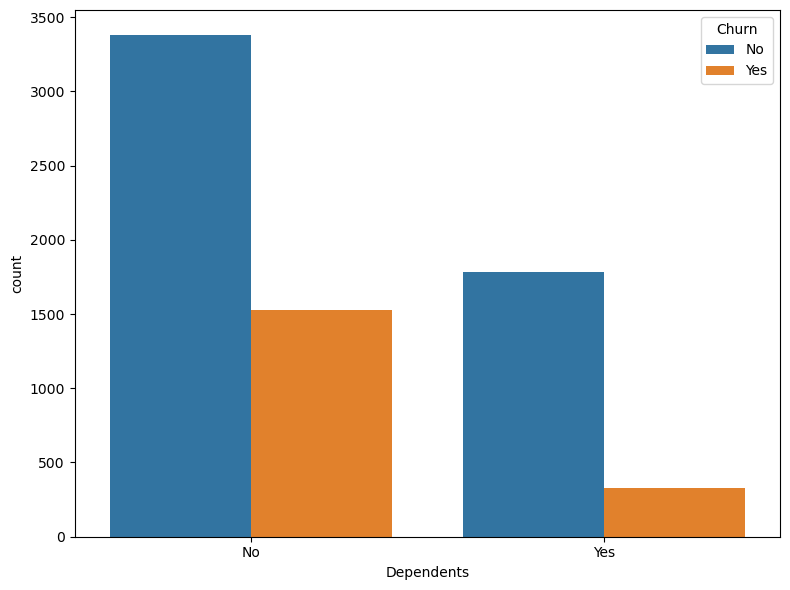

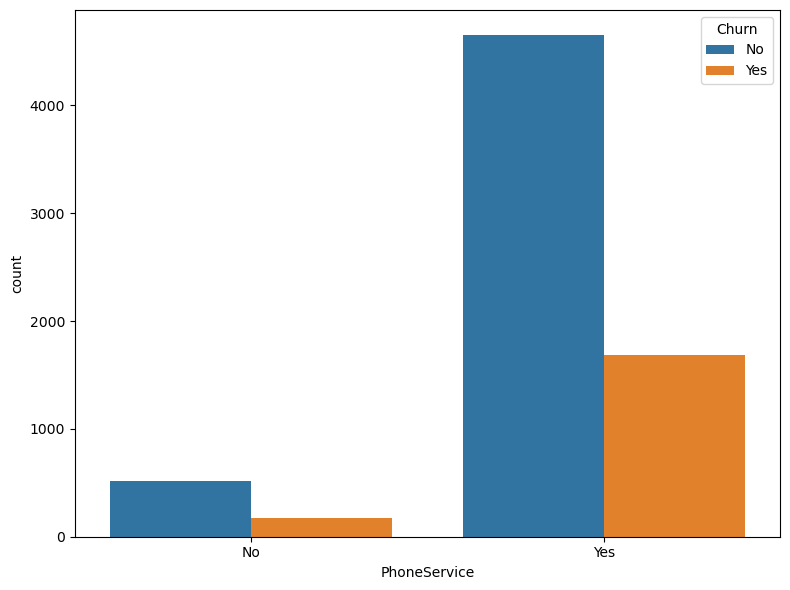

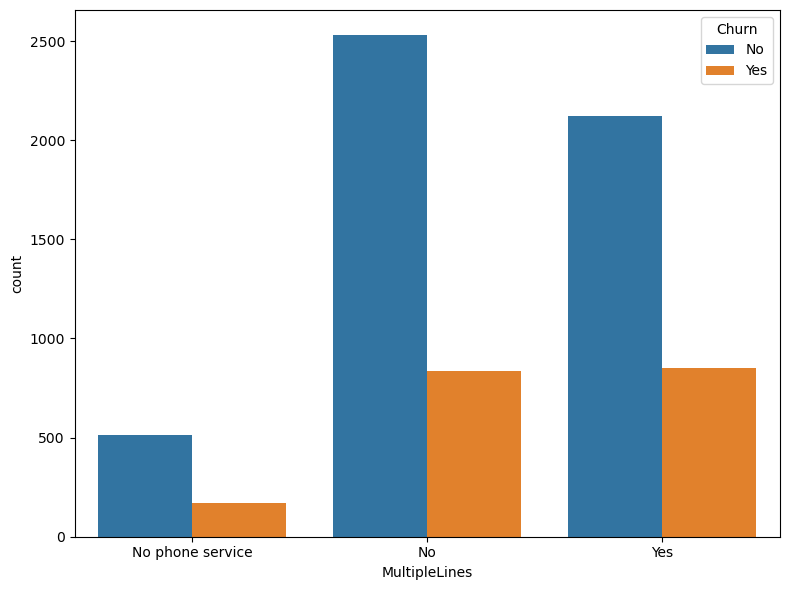

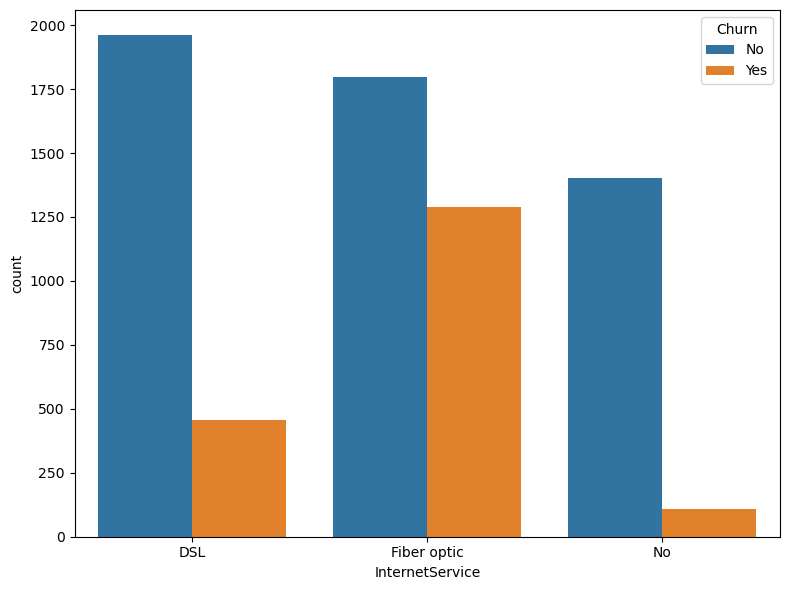

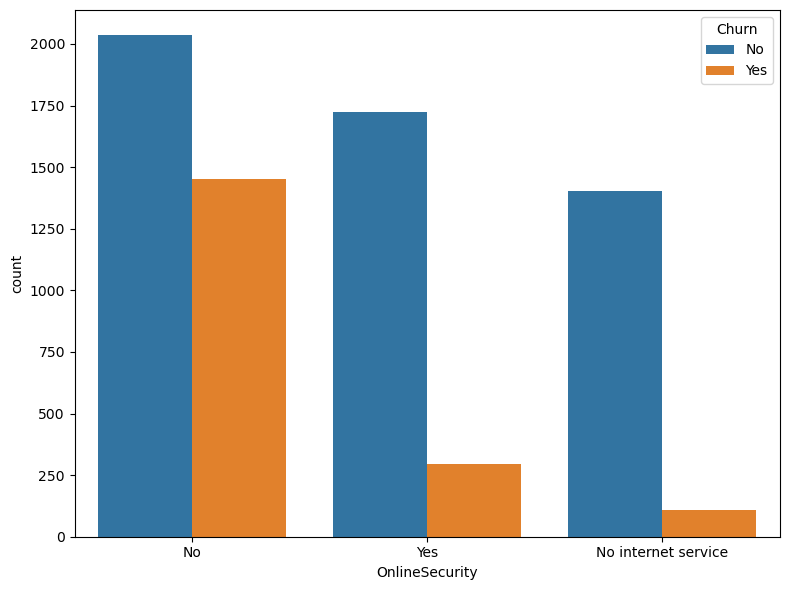

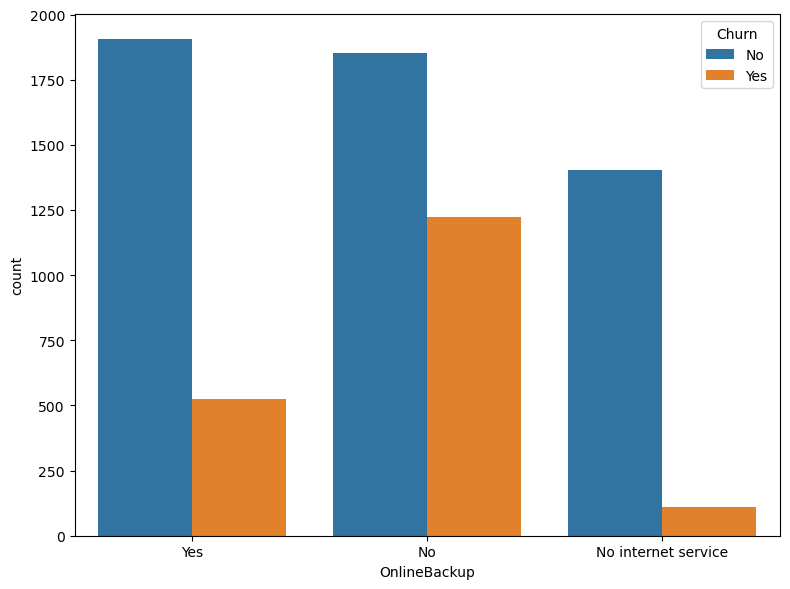

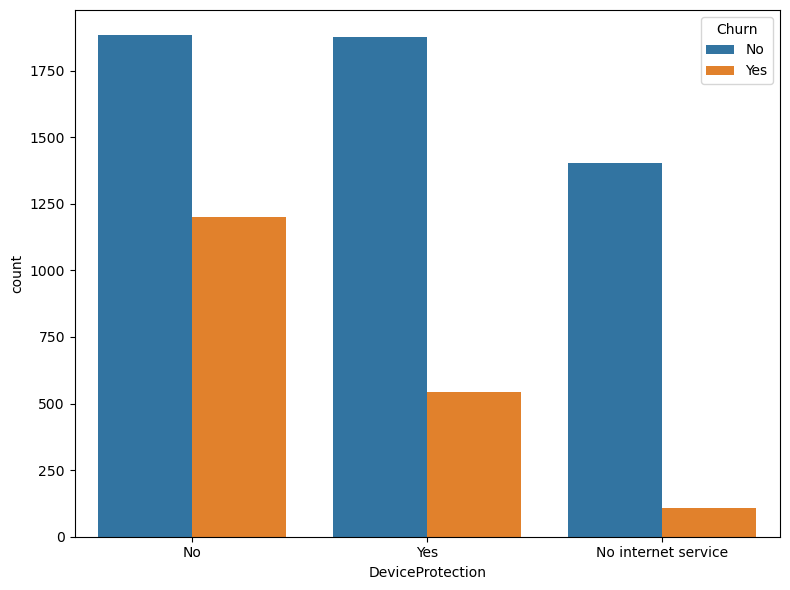

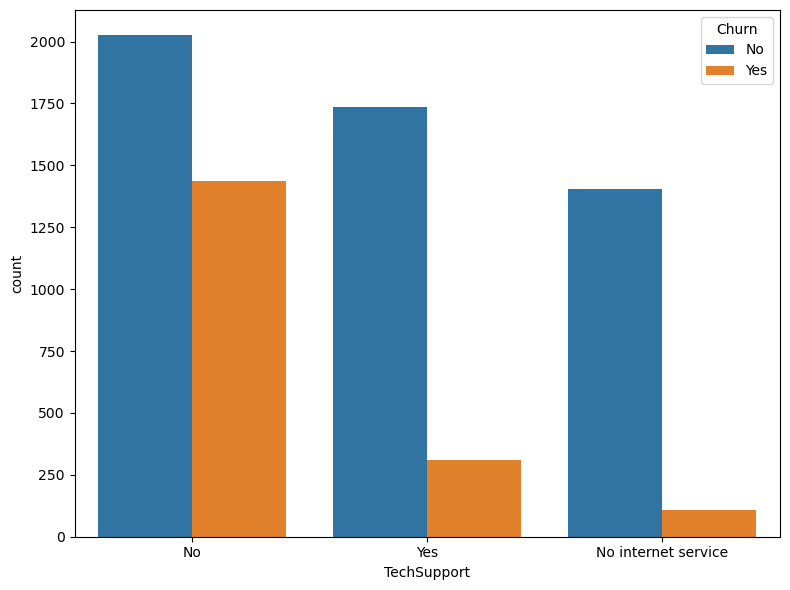

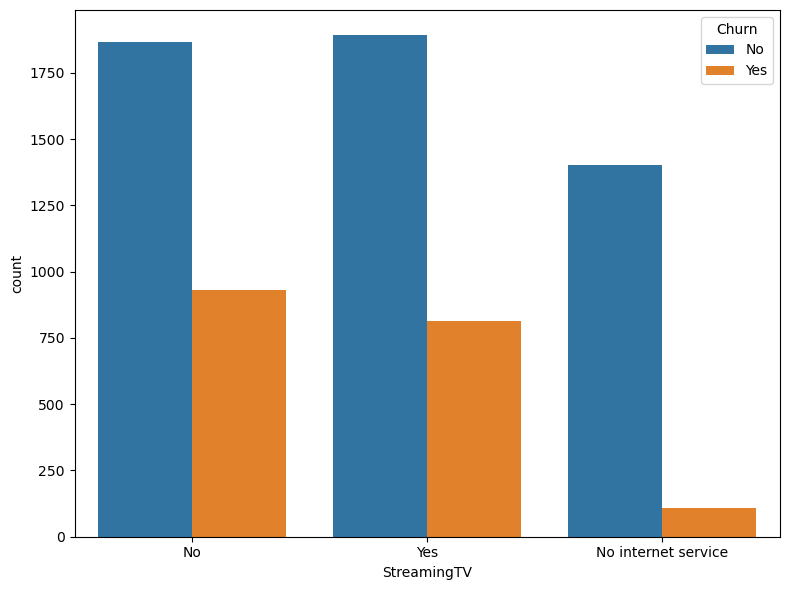

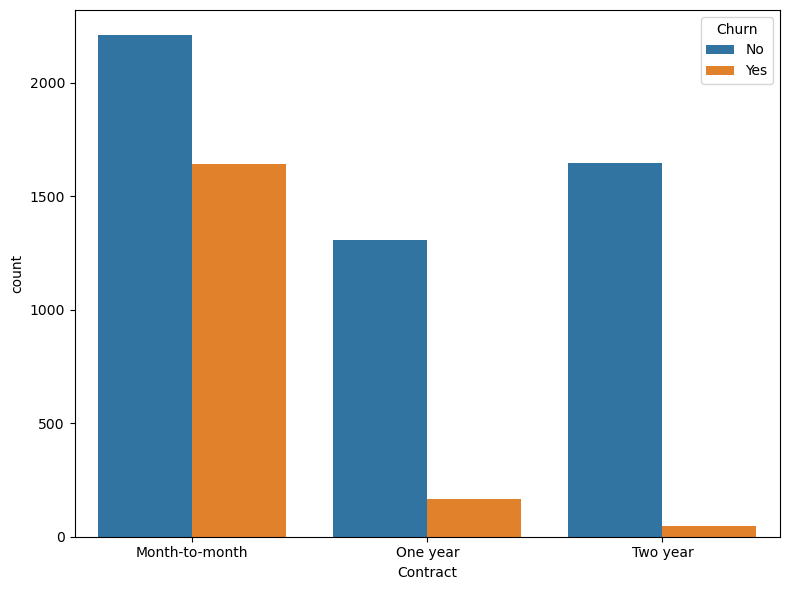

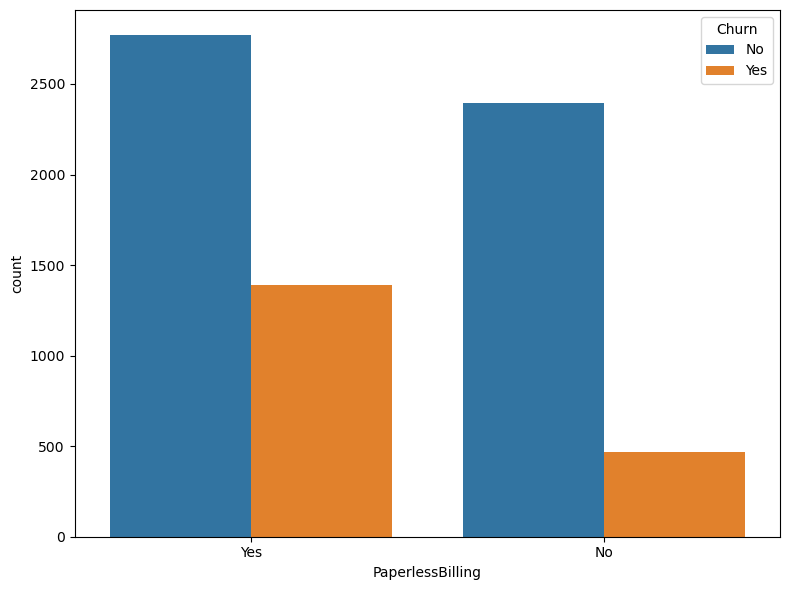

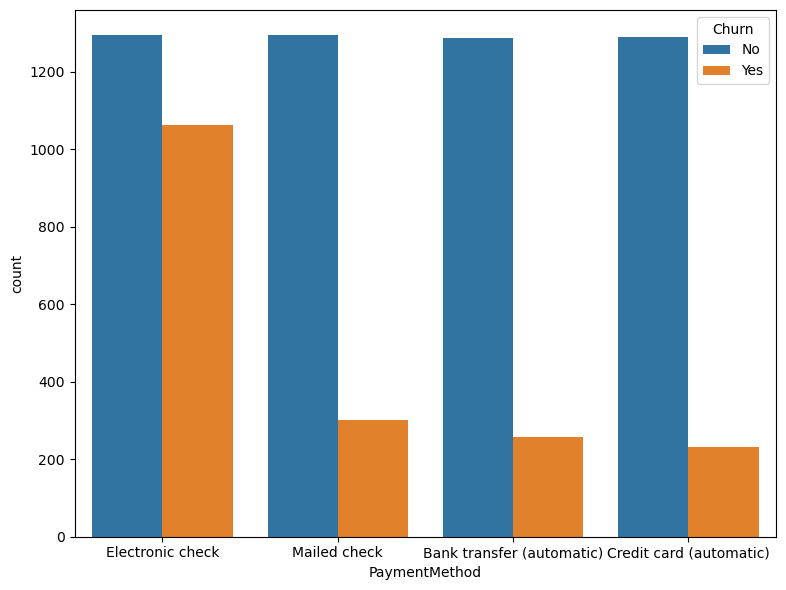

In [633]:
for col in cat_col:
    plt.figure(figsize=(8,6))
    sns.countplot(x=df[col], hue=df['Churn'])
    plt.tight_layout()

# Data Preprocessing

In [634]:
df.head()

,Gender,Partner,Dependents,TenureMonths,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [635]:
# converting 'Churn' yes and no to 0 and 1

df['Churn'] = df['Churn'].replace({'Yes':1, 'No':0})

<Axes: >

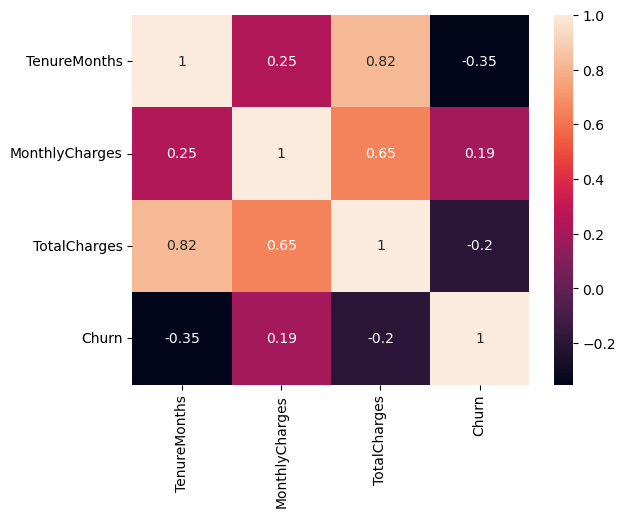

In [636]:
# heatmap

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [637]:
# creating X and y

X = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

In [638]:
# encoding

X = pd.get_dummies(X, drop_first=True).astype(int)
X.head()

,TenureMonths,MonthlyCharges,TotalCharges,Gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29,29,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,34,56,1889,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2,53,108,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,45,42,1840,1,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
4,2,70,151,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0


# Classification Models

In [639]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [640]:
# data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [641]:
# scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [642]:
# model training

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(),
    'SVM': SVC()
}

results = []

In [643]:
models.items()

dict_items([('Logistic Regression', LogisticRegression()), ('KNN', KNeighborsClassifier()), ('Naive Bayes', GaussianNB()), ('DecisionTree', DecisionTreeClassifier()), ('SVM', SVC())])

In [644]:
# model testing & evaluation

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'model': name,
        'accuracy score': round(acc,4),
        'f1 score': round(f1, 4)
    })

In [645]:
results

[{'model': 'Logistic Regression',
  'accuracy score': 0.8091,
  'f1 score': 0.6093},
 {'model': 'KNN', 'accuracy score': 0.7614, 'f1 score': 0.5405},
 {'model': 'Naive Bayes', 'accuracy score': 0.6467, 'f1 score': 0.5507},
 {'model': 'DecisionTree', 'accuracy score': 0.7044, 'f1 score': 0.4338},
 {'model': 'SVM', 'accuracy score': 0.8162, 'f1 score': 0.5956}]

In [646]:
# best model - Logistic Pregression

In [647]:
# saving model

In [648]:
import joblib

In [649]:
joblib.dump(models['Logistic Regression'], 'telco_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']